In [78]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import find_combination, create_DS



import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

c0 ={'acc':'#941717', 'coriolis':'#388E3C','ggrad':'#42A5F5', 'wind':'#FFA000'}

_______
# Data

In [81]:
dfc = pd.read_csv(os.path.join(zarr_dir, 'coloc_nearest.csv')).set_index('row_number')
id_comb = find_combination(dfc)
DS = create_DS(dfc, id_comb)
DSS = DS.where(DS.drifter_type.isin(surface_drifters), drop=True).sel(id_comb = 'eta_swot250gauss1e3__0era5')
DSD = DS.where(DS.drifter_type.isin(depth_drifters), drop=True).sel(id_comb = 'eta_swot250gauss1e3__15era5')

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/core/dataset.py:4789: UserWarning: No index created for dimension id_comb because variable id_comb is not a coordinate. To create an index for id_comb, please first call `.set_coords('id_comb')` on this object.
  warnings.warn(


______
# Distribution

In [94]:
DSS.sume.min(), DSS.sume.max()

(<xarray.DataArray 'sume' ()> Size: 8B
 array(-0.00010443)
 Coordinates:
     id_comb  <U63 252B 'eta_swot250gauss1e3__0era5',
 <xarray.DataArray 'sume' ()> Size: 8B
 array(9.86454282e-05)
 Coordinates:
     id_comb  <U63 252B 'eta_swot250gauss1e3__0era5')

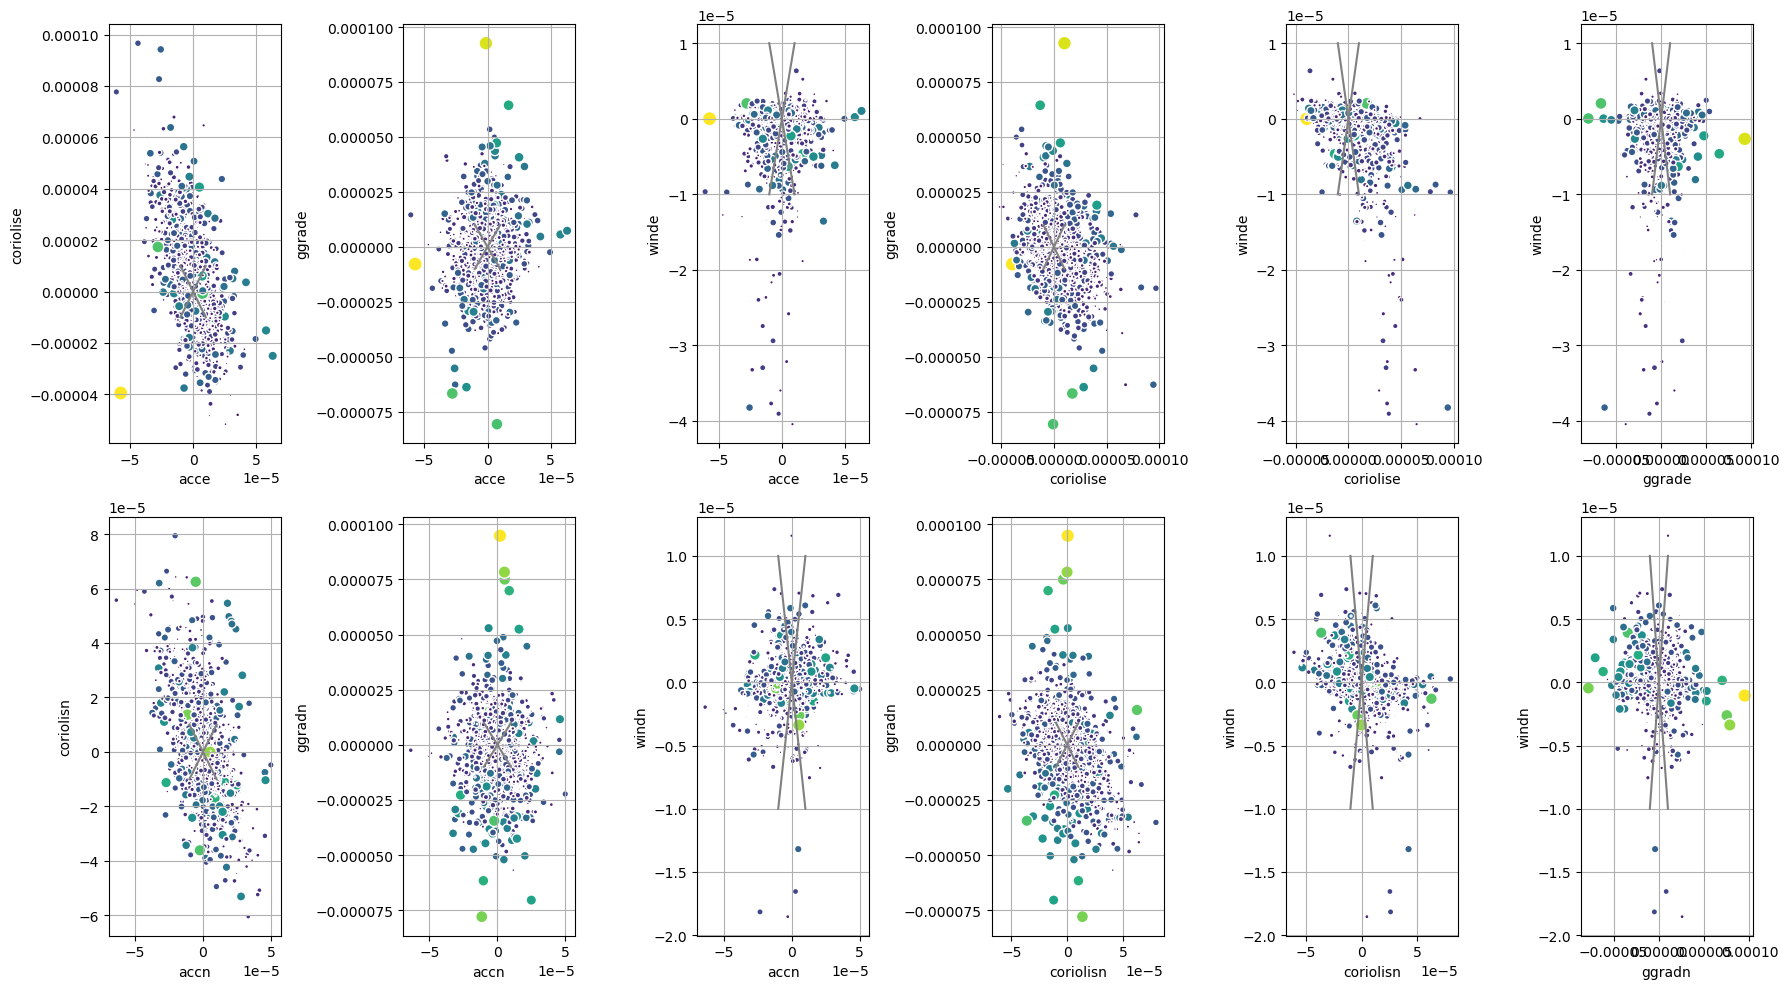

In [106]:
fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(18, 10))
axs =axs.flatten()

s = abs(DSS.sume*1e6)
c = abs(DSS.sume*1e6)

DSS.plot.scatter(x='acce', y='coriolise', s = s,c=c, ax=axs[0])
DSS.plot.scatter(x='acce', y='ggrade', s = s,c=c, ax=axs[1])
DSS.plot.scatter(x='acce', y='winde', s = s,c=c, ax=axs[2])
DSS.plot.scatter(x='coriolise', y='ggrade', s = s,c=c, ax=axs[3])
DSS.plot.scatter(x='coriolise', y='winde', s = s,c=c, ax=axs[4])
DSS.plot.scatter(x='ggrade', y='winde', s = s,c=c, ax=axs[5])

s = abs(DSS.sumn*1e6)
c = abs(DSS.sumn*1e6)
DSS.plot.scatter(x='accn', y='coriolisn', s = s,c=c, ax=axs[6])
DSS.plot.scatter(x='accn', y='ggradn', s = s,c=c, ax=axs[7])
DSS.plot.scatter(x='accn', y='windn', s = s,c=c, ax=axs[8])
DSS.plot.scatter(x='coriolisn', y='ggradn', s = s,c=c, ax=axs[9])
DSS.plot.scatter(x='coriolisn', y='windn', s = s,c=c, ax=axs[10])
DSS.plot.scatter(x='ggradn', y='windn', s = s,c=c, ax=axs[11])

for ax in axs:
    ax.grid()
    ax.set_title('')
    ax.plot(x, x, c='grey')
    ax.plot(x, -x, c='grey')

fig.tight_layout()

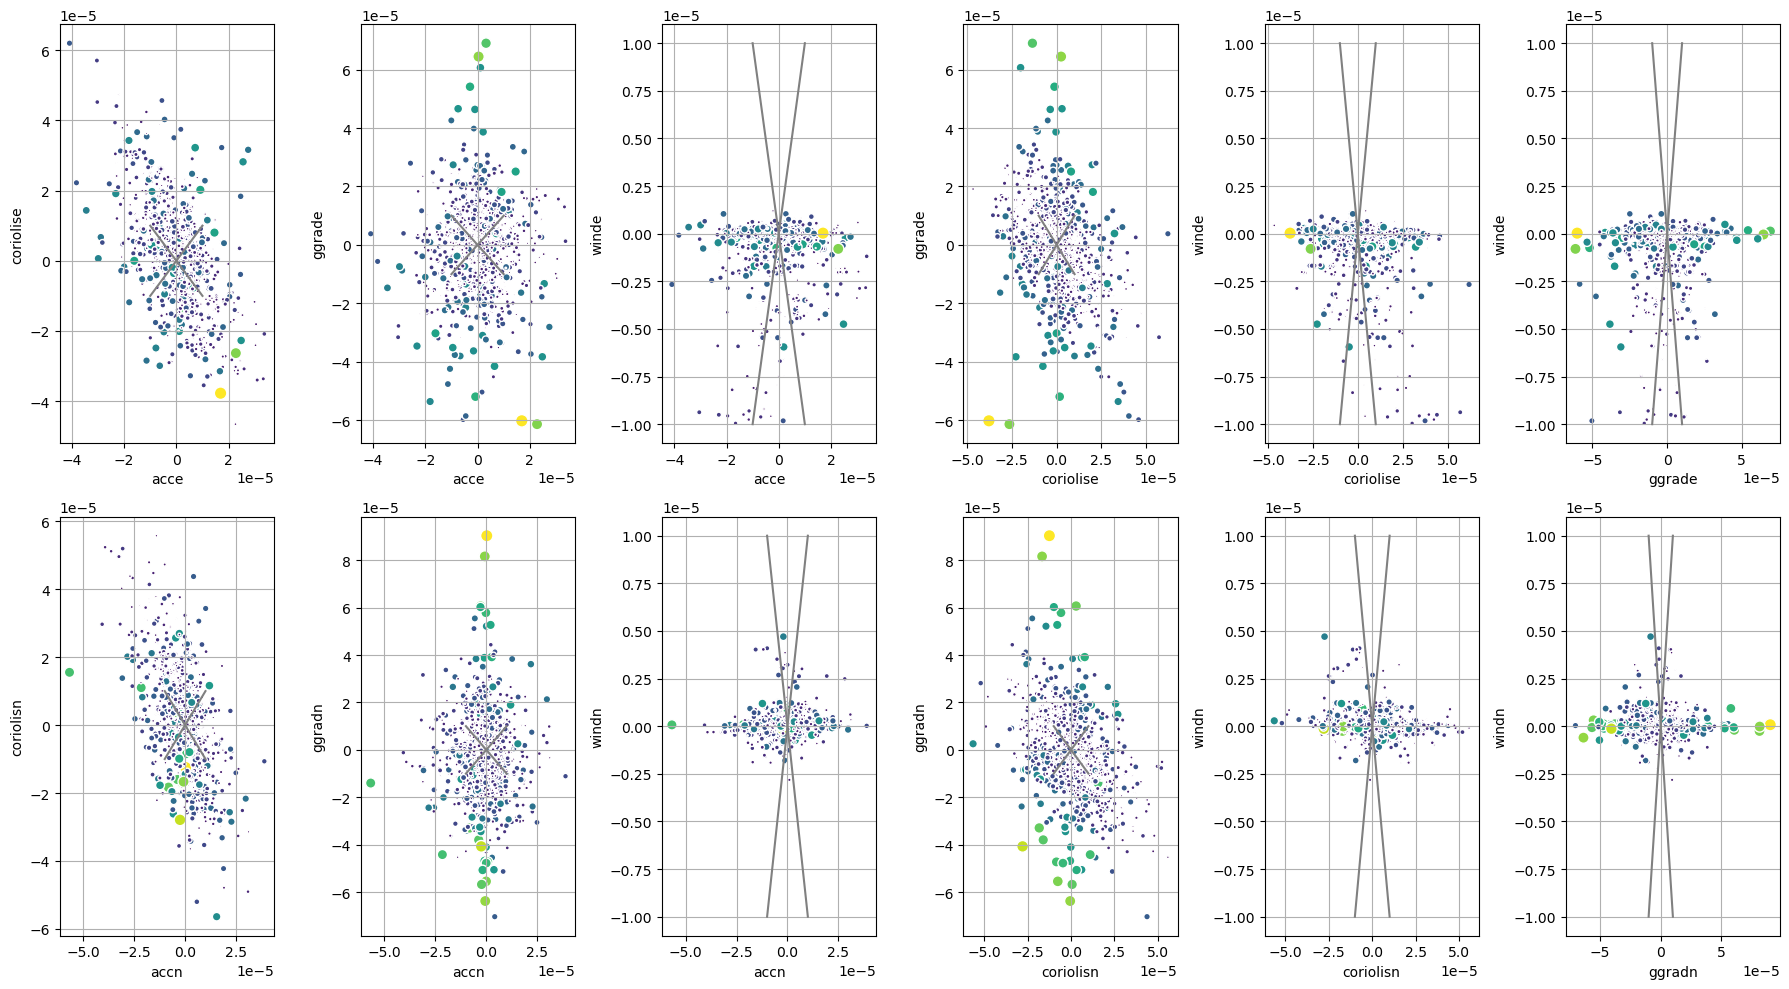

In [105]:
fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(18, 10))
axs =axs.flatten()

s = abs(DSD.sume*1e6)
c = abs(DSD.sume*1e6)

DSD.plot.scatter(x='acce', y='coriolise', s = s,c=c, ax=axs[0])
DSD.plot.scatter(x='acce', y='ggrade', s = s,c=c, ax=axs[1])
DSD.plot.scatter(x='acce', y='winde', s = s,c=c, ax=axs[2])
DSD.plot.scatter(x='coriolise', y='ggrade', s = s,c=c, ax=axs[3])
DSD.plot.scatter(x='coriolise', y='winde', s = s,c=c, ax=axs[4])
DSD.plot.scatter(x='ggrade', y='winde', s = s,c=c, ax=axs[5])

s = abs(DSD.sumn*1e6)
c = abs(DSD.sumn*1e6)
DSD.plot.scatter(x='accn', y='coriolisn', s = s,c=c, ax=axs[6])
DSD.plot.scatter(x='accn', y='ggradn', s = s,c=c, ax=axs[7])
DSD.plot.scatter(x='accn', y='windn', s = s,c=c, ax=axs[8])
DSD.plot.scatter(x='coriolisn', y='ggradn', s = s,c=c, ax=axs[9])
DSD.plot.scatter(x='coriolisn', y='windn', s = s,c=c, ax=axs[10])
DSD.plot.scatter(x='ggradn', y='windn', s = s,c=c, ax=axs[11])


x = np.arange(-1e-5, 1e-5, 1e-6)
for ax in axs:
    ax.grid()
    ax.plot(x, x, c='grey')
    ax.plot(x, -x, c='grey')
    
    ax.set_title('')

fig.tight_layout()

In [6]:
from sklearn.cluster import KMeans 
import pandas as pd

In [39]:
DS

<xarray.Dataset> Size: 11MB
Dimensions:               (id_comb: 16, index: 2340, dim_0: 2340)
Coordinates:
    datetime              (id_comb, index) object 300kB '2023-04-01 23:40:00'...
    longitude             (id_comb, index) float64 300kB 5.632 5.559 ... 1.789
    latitude              (id_comb, index) float64 300kB 42.26 42.88 ... 39.33
    pass_number           (id_comb, index) int64 300kB 3 3 3 3 3 ... 16 16 16 16
    time_to_swot          (id_comb, index) object 300kB '0 days 00:02:32.6965...
    cycle_number          (id_comb, index) int64 300kB 478 478 478 ... 577 577
    drifter_id            (id_comb, index) object 300kB '0-4351296' ... '3005...
    drifter_type          (id_comb, index) object 300kB 'CARTHE' ... 'SVP'
  * id_comb               (id_comb) <U63 4kB 'duacs_ssha_karin_2_filtered_swo...
  * index                 (index) int64 19kB 0 1 2 3 4 ... 2336 2337 2338 2339
  * dim_0                 (dim_0) int64 19kB 0 1 2 3 4 ... 2336 2337 2338 2339
Data variables: (12/30)
    sume                  (id_comb, dim_0) float64 300kB -1.606e-05 ... 4.012...
    acce                  (id_comb, dim_0) float64 300kB -1.517e-05 ... 4.783...
    exce_acc              (id_comb, dim_0) float64 300kB -8.948e-07 ... 3.533...
    coriolise             (id_comb, dim_0) float64 300kB 4.449e-05 ... 2.402e-07
    exce_coriolis         (id_comb, dim_0) float64 300kB -6.055e-05 ... 3.771...
    ggrade                (id_comb, dim_0) float64 300kB -1.795e-05 ... 3.139...
    ...                    ...
    prodn_acc_coriolis    (id_comb, dim_0) float64 300kB -6.065e-10 ... 9.586...
    prodn_acc_ggrad       (id_comb, dim_0) float64 300kB 2.959e-10 ... -4.973...
    prodn_acc_wind        (id_comb, dim_0) float64 300kB 4.249e-10 ... 9.189e-13
    prodn_coriolis_ggrad  (id_comb, dim_0) float64 300kB -3.277e-10 ... -2.32...
    prodn_coriolis_wind   (id_comb, dim_0) float64 300kB -4.707e-10 ... 4.302...
    prodn_ggrad_wind      (id_comb, dim_0) float64 300kB 2.296e-10 ... -2.232...

In [27]:
X = dfc[['acce', 'coriolise']]
kmeans = KMeans(n_clusters=5)
kmeans.fit(X) 
labels = kmeans.predict(X)

In [28]:
labels

array([3, 3, 3, ..., 2, 0, 2], dtype=int32)

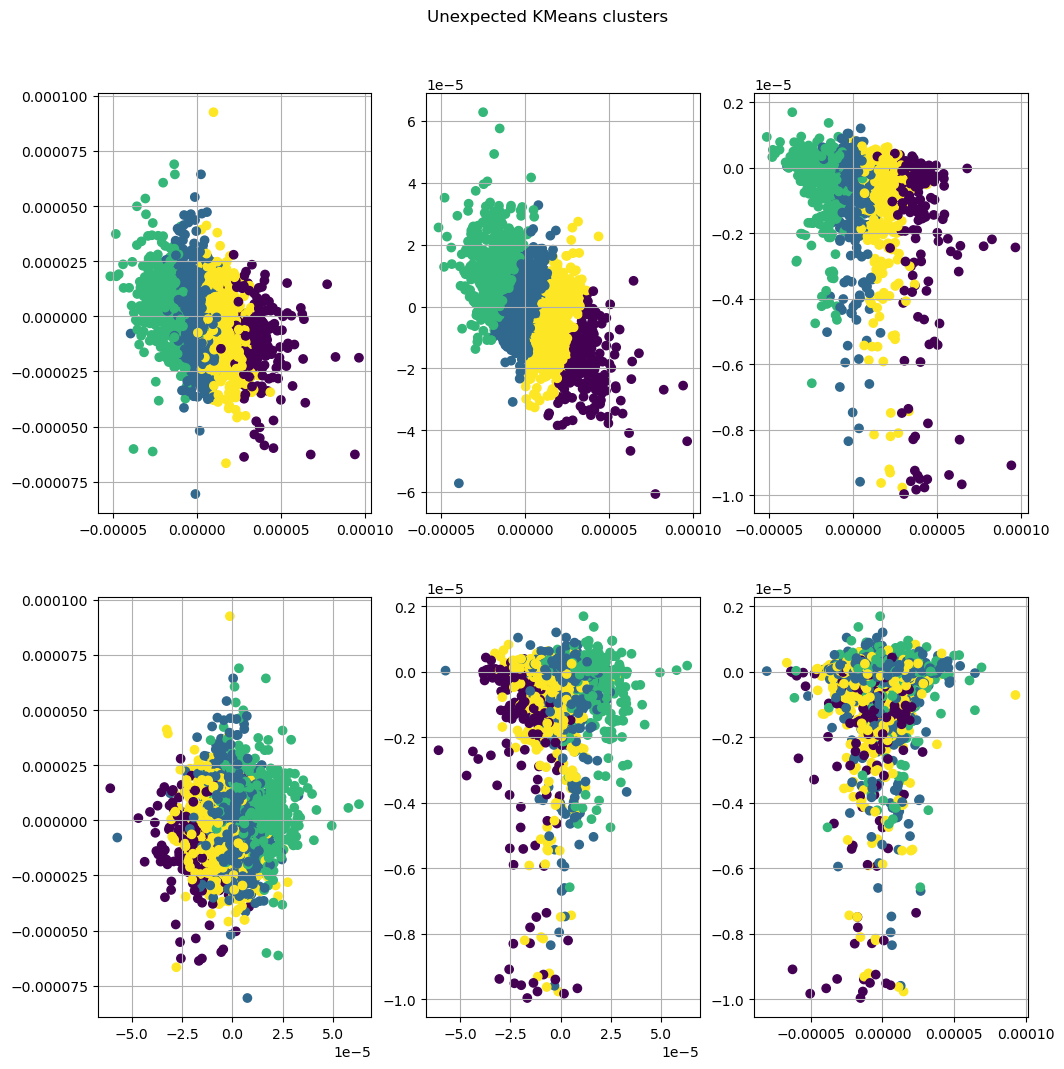

In [33]:
from sklearn.cluster import KMeans

common_params = {
    "n_init": "auto",
}

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 12))
axs =axs.flatten()
y_pred = KMeans(n_clusters=4, **common_params).fit_predict(X)
axs[0].scatter(dfc.coriolise, dfc.ggrade_eta_swot250gauss1e3, c=y_pred, s=)
axs[1].scatter(dfc.coriolise, dfc.acce, c=y_pred)
axs[2].scatter(dfc.coriolise, dfc.winde15_era5, c=y_pred)
axs[3].scatter(dfc.acce, dfc.ggrade_eta_swot250gauss1e3, c=y_pred)
axs[4].scatter(dfc.acce, dfc.winde15_era5, c=y_pred)
axs[5].scatter(dfc.ggrade_eta_swot250gauss1e3, dfc.winde15_era5, c=y_pred)

#axs[0, 0].set_title("Non-optimal Number of Clusters")
for ax in axs:
    ax.grid()
    
plt.suptitle("Unexpected KMeans clusters").set_y(0.95)
plt.show()